In [ ]:
import os
from experiments.CUP.common import run_cup_selection

SEEDS = [42]
TOP_K = 10

CONFIG_CUP = "experiments/CUP/configs/cup.yaml"
OUT_CUP = "experiments/CUP/results/cup"

os.makedirs(OUT_CUP, exist_ok=True)

print("\n==============================")
print("Running CUP model selection")
print("==============================")

out_cup = run_cup_selection(
    config_path=CONFIG_CUP,
    out_dir=OUT_CUP,
    seeds=SEEDS,
    top_k=TOP_K,
)

print("CUP DONE")
print("Best score:", out_cup["best_score"])


Running MONK-1 model selection
[grid:holdout] 1/1296 config_id=f6546afc5813 seed=42
[grid:holdout] 2/1296 config_id=28254568b15d seed=42
[grid:holdout] 3/1296 config_id=c3d171a89935 seed=42
[grid:holdout] 4/1296 config_id=445dd0a80a63 seed=42
[grid:holdout] 5/1296 config_id=7c729cdc112c seed=42
[grid:holdout] 6/1296 config_id=d17cfcbd21c8 seed=42
[grid:holdout] 7/1296 config_id=7457af011561 seed=42
[grid:holdout] 8/1296 config_id=601a6f952ade seed=42
[grid:holdout] 9/1296 config_id=0020f552137f seed=42
[grid:holdout] 10/1296 config_id=5ccf3799dce0 seed=42
[grid:holdout] 11/1296 config_id=9cd58eb5555a seed=42
[grid:holdout] 12/1296 config_id=c5e18cb58c0c seed=42
[grid:holdout] 13/1296 config_id=ca9ad25cc074 seed=42
[grid:holdout] 14/1296 config_id=5c3062177729 seed=42
[grid:holdout] 15/1296 config_id=e877430363a9 seed=42
[grid:holdout] 16/1296 config_id=833a6bda4e2b seed=42
[grid:holdout] 17/1296 config_id=9afcb4f00c21 seed=42
[grid:holdout] 18/1296 config_id=cc71c844adf4 seed=42
[grid

In [1]:
import sys
import os

# Aggiunge la root al path
sys.path.append(os.getcwd())

# Importiamo il modulo common appena creato
from experiments.CUP import common

# --- CONFIGURAZIONE ---
CUP_ORIGINAL  = 'data/CUP/ML-CUP25-TR.csv' # Assicurati che il file sia qui
INT_TRAIN     = 'data/CUP/internal_train_80.csv'
INT_TEST      = 'data/CUP/internal_test_20.csv'
CONFIG_PATH   = 'experiments/CUP/configs/cup_coarse.yaml'
RESULTS_DIR   = 'experiments/CUP/results/cup_exp_1'

# --- 1. PREPARAZIONE DATI ---
# Crea lo split 80/20 salvando i file in formato compatibile con load_cup
common.create_internal_split(
    original_path=CUP_ORIGINAL, 
    train_save_path=INT_TRAIN, 
    test_save_path=INT_TEST,
    test_ratio=0.15
)

# --- 2. GRID SEARCH & MODEL SELECTION ---
# Esegue Coarse Search (Holdout) -> Selezione Top K -> Fine Search (K-Fold)
# Tutto automatico come per il MONK
print("\nAvvio Model Selection...")
best_result = common.run_cup_selection(
    config_path=CONFIG_PATH,
    out_dir=RESULTS_DIR,
    seeds=[42], # Puoi aggiungere altri seed se vuoi robustezza
    top_k=10,
    n_jobs = -1
)

print(f"\nExperiment completed. Results in: {RESULTS_DIR}")
print(f"Best Configuration found: {best_result['best_config']}")

[CUP] Loading raw: data/CUP/ML-CUP25-TR.csv
[CUP] Saved split: data/CUP/internal_train_80.csv, data/CUP/internal_test_20.csv

Avvio Model Selection...
Starting Grid Search with 8 processes for 3888 tasks...
[grid:holdout] 1/3888 Config completata.
[grid:holdout] 2/3888 Config completata.
[grid:holdout] 3/3888 Config completata.
[grid:holdout] 4/3888 Config completata.
[grid:holdout] 5/3888 Config completata.
[grid:holdout] 6/3888 Config completata.
[grid:holdout] 7/3888 Config completata.
[grid:holdout] 8/3888 Config completata.
[grid:holdout] 9/3888 Config completata.
[grid:holdout] 10/3888 Config completata.
[grid:holdout] 11/3888 Config completata.
[grid:holdout] 12/3888 Config completata.
[grid:holdout] 13/3888 Config completata.
[grid:holdout] 14/3888 Config completata.
[grid:holdout] 15/3888 Config completata.
[grid:holdout] 16/3888 Config completata.
[grid:holdout] 17/3888 Config completata.
[grid:holdout] 18/3888 Config completata.
[grid:holdout] 19/3888 Config completata.
[gri

: 

: 

- vedi dov'è salvato il modello finale e in che modo

In [21]:
best_config = best_result['best_config']
best_config

{'callbacks': {'early_stopping': True,
  'min_delta': '1e-5',
  'mode': 'min',
  'monitor': 'val_loss',
  'patience': 50,
  'restore_best_weights': True,
  'verbose': 0},
 'cv': {'k': 5, 'seed': 42, 'shuffle': True},
 'data': {'inputs': 12,
  'normalize': True,
  'targets': 4,
  'train_path': 'data/CUP/internal_train_80.csv'},
 'model': {'activation': 'relu',
  'dropout': 0.0,
  'hidden_units': [8, 6],
  'output_activation': 'linear'},
 'optim': {'lr': 0.001, 'momentum': 0.7, 'name': 'sgd'},
 'regularizer': {'l2': 0.08},
 'seed': 42,
 'split': {'stratified': False, 'val_size': 0.2},
 'training': {'batch_size': 32,
  'epochs': 800,
  'include_reg_in_val': False,
  'loss': 'mee',
  'metric': 'mee',
  'shuffle': True}}

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aggiunge la root al path
sys.path.append(os.getcwd())

from experiments.CUP import common
from training.trainer import Trainer
from training.gridsearch import _hash_config # Per trovare l'ID della config
from data_handler.data_loader import normalize
from nn.metrics import MEE

# --- CONFIGURAZIONE PATH ---
RESULTS_DIR = 'experiments/CUP/results/cup_exp_1' # La tua cartella risultati
BEST_CONFIG_PATH = os.path.join(RESULTS_DIR, 'best_config.json')
FINE_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'fine_summary.csv')

INT_TRAIN = 'data/CUP/internal_train_80.csv'
INT_TEST  = 'data/CUP/internal_test_20.csv'

print("=== 1. RECUPERO CONFIGURAZIONE E BEST EPOCH ===")

# A. Carica la Best Config
if not os.path.exists(BEST_CONFIG_PATH):
    raise FileNotFoundError(f"Non trovo il file {BEST_CONFIG_PATH}. Hai lanciato la grid search?")

with open(BEST_CONFIG_PATH, 'r') as f:
    best_config = json.load(f)

# B. Recupera la Best Epoch media dal summary della fine search
# Calcoliamo l'ID della config per trovarla nel CSV
config_id = _hash_config(best_config)
print(f"Best Config ID: {config_id}")

df_summary = pd.read_csv(FINE_SUMMARY_PATH)
# Cerca la riga corrispondente
row = df_summary[df_summary['config_id'] == config_id]

if row.empty:
    print("WARNING: Config ID non trovato nel summary. Uso le epoche di default del config.")
    best_epoch = best_config['training']['epochs']
else:
    # Prende la media delle migliori epoche (best_epoch_mean)
    mean_epoch = row['best_epoch_mean'].values[0]
    best_epoch = int(round(mean_epoch))
    print(f"Best Epoch (Mean over Folds): {mean_epoch:.2f} -> Usiamo: {best_epoch}")

print(f"\nConfigurazione scelta: {best_config['model']}")
print(f"Hyperparams: LR={best_config['optim']['lr']}, Momentum={best_config['optim']['momentum']}")

# === 2. PREPARAZIONE DATI (DEV + TEST) ===
print("\n=== 2. DATA LOADING & NORMALIZATION ===")

# Carichiamo i dati GREZZI
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
X_test_raw, y_test_raw = common.load_cup(INT_TEST, training=True)

# Logica di Normalizzazione (Fit su Dev -> Transform su Test)
do_normalize = best_config.get('data', {}).get('normalize', False)

if do_normalize:
    print("-> Normalizzazione Attiva (Fit on Dev, Transform on Test)")
    X_dev, mean_x, std_x = normalize(X_dev_raw)
    X_test, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)
else:
    print("-> Nessuna normalizzazione.")
    X_dev, X_test = X_dev_raw, X_test_raw

# ==========================================
# 3. RETRAINING & ASSESSMENT FINALE (CORRETTO)
# ==========================================
print("\n=== Retraining Best Model on Full Development Set ===")

# 1. Recupera la Best Config (Ce l'hai già dalla Sezione 1, non serve ricaricarla se è in memoria)
# best_config = best_result['best_config'] # Usa quella già caricata e processata

# 2. Carica i dati GREZZI
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
X_test_raw, y_test_raw = common.load_cup(INT_TEST, training=True)

# 3. Normalizzazione Manuale
do_normalize = best_config.get('data', {}).get('normalize', False)

if do_normalize:
    print("-> Normalizzazione Attiva (Fit on Dev, Transform on Test)")
    X_dev, mean_x, std_x = normalize(X_dev_raw)
    X_test, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)
else:
    print("-> Nessuna normalizzazione.")
    X_dev, X_test = X_dev_raw, X_test_raw

# 4. Modifica Config per Retraining Fisso
# IMPORTANTE: Usiamo la best_epoch calcolata nella Sezione 1!
print(f"-> Impostazione epoche fisse: {best_epoch} (media dai fold)")
final_epochs = best_epoch 

# IMPORTANTE: Disabilitiamo Early Stopping per garantire che arrivi in fondo
# Se early_stopping è attivo, potrebbe fermarsi prima, invalidando la statistica della media.
if 'callbacks' in best_config and 'early_stopping' in best_config['callbacks']:
    print("-> Disabilitazione Early Stopping per il retraining.")
    best_config['callbacks']['early_stopping'] = False

# 5. Costruzione Modello
final_model = common.build_model(best_config, seed=42)
trainer = Trainer(final_model, verbose=1)

# 6. Training
history = trainer.fit(
    X_train=X_dev, 
    y_train=y_dev,
    X_val=X_test, 
    y_val=y_test_raw, 
    epochs=final_epochs, # <--- USA LA VARIABILE CALCOLATA
    batch_size=best_config['training']['batch_size'],
    include_reg_in_val=False
)

# 7. Estrazione Storico
history_data = history.to_dict()
train_loss = history_data['loss']
if 'val_loss' in history_data:
    val_loss = history_data['val_loss']
else:
    val_loss = []

# 8. Assessment Finale
y_pred = final_model.predict(X_test)
mee_metric = MEE()
final_mee = mee_metric.compute(y_pred, y_test_raw)

# print(f"\n" + "="*50)
# print(f"RISULTATO FINALE (Internal Test 20%)")
# print(f"MEE: {final_mee:.5f}")
# print("="*50)

=== 1. RECUPERO CONFIGURAZIONE E BEST EPOCH ===
Best Config ID: 366925f87d0a
Best Epoch (Mean over Folds): 220.60 -> Usiamo: 221

Configurazione scelta: {'activation': 'relu', 'dropout': 0.0, 'hidden_units': [8, 6], 'output_activation': 'linear'}
Hyperparams: LR=0.001, Momentum=0.7

=== 2. DATA LOADING & NORMALIZATION ===
-> Normalizzazione Attiva (Fit on Dev, Transform on Test)

=== Retraining Best Model on Full Development Set ===
-> Normalizzazione Attiva (Fit on Dev, Transform on Test)
-> Impostazione epoche fisse: 221 (media dai fold)
-> Disabilitazione Early Stopping per il retraining.

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/221 [>.............................] loss: 1466.6204 MSE: 1465.8296 val_loss: 1498.4238 val_MSE: 1498.4238Epoch 2/221 [>.............................] loss: 1070.4987 MSE: 


=== Generazione K-Fold Learning Curve (Early Stopping Attivo) ===
Max Epochs impostate: 800
Early Stopping: False
Esecuzione 5-Fold CV...

Starting 5-Fold Cross Validation
Elaborazione curve di lunghezza diversa...


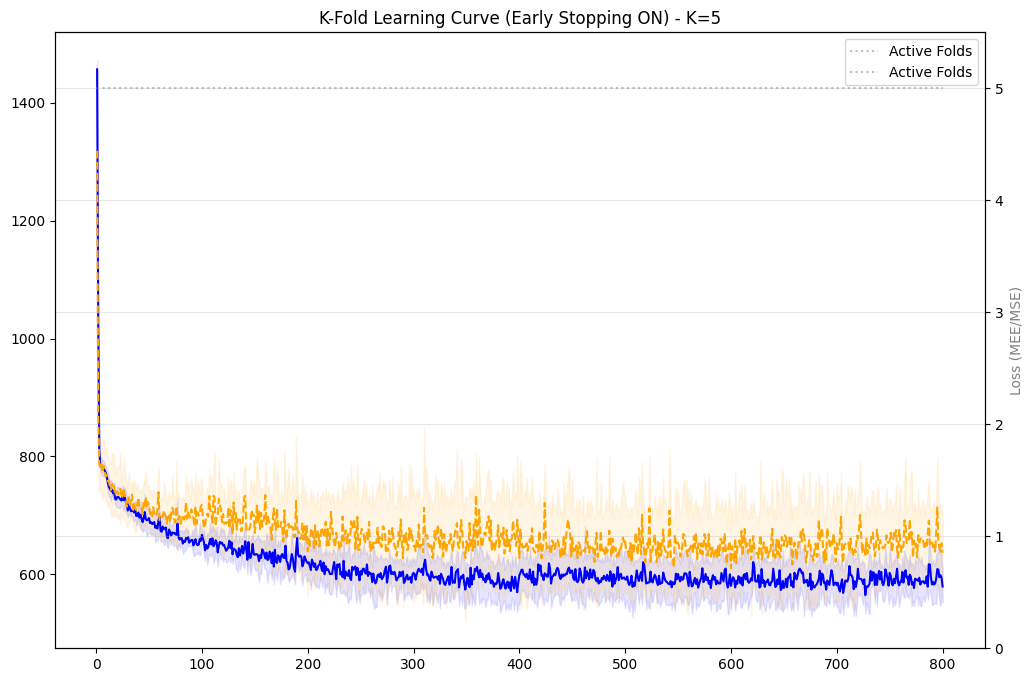

Durata media: 800 epoche
Loss Val Finale (Ultimo punto valido): 636.14210


In [3]:
# ==========================================
# 4. LEARNING CURVE CON K-FOLD (Early Stopping ATTIVO)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import warnings  # <--- CORREZIONE: Importiamo il modulo standard
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer

print("\n=== Generazione K-Fold Learning Curve (Early Stopping Attivo) ===")

# 1. Configurazione
run_config = best_config.copy()
# (Opzionale) Aumenta le epoche se vuoi stressare l'Early Stopping
# run_config['training']['epochs'] = 1000 

print(f"Max Epochs impostate: {run_config['training']['epochs']}")
if 'callbacks' in run_config and 'early_stopping' in run_config['callbacks']:
    print(f"Early Stopping: {run_config['callbacks']['early_stopping']}")
else:
    print("Early Stopping non trovato nel config.")

k_folds = 5 

# 2. Dati
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
do_normalize = run_config.get('data', {}).get('normalize', False)

# 3. Esecuzione K-Fold
model_dummy = common.build_model(run_config, seed=42)
trainer_dummy = Trainer(model_dummy, verbose=0)

print(f"Esecuzione {k_folds}-Fold CV...")
_, _, histories, _ = kfold_cross_validation(
    X=X_dev_raw,
    y=y_dev,
    model=model_dummy,
    trainer=trainer_dummy,
    k=k_folds,
    epochs=run_config['training']['epochs'],
    batch_size=run_config['training']['batch_size'],
    shuffle=True,
    seed=42,
    verbose=0,
    normalize_data=do_normalize,
    include_reg_in_val=False 
)

# 4. GESTIONE LUNGHEZZE VARIABILI (Padding)
print("Elaborazione curve di lunghezza diversa...")

try:
    train_losses_list = [h.to_dict()['loss'] for h in histories]
    val_losses_list = [h.to_dict()['val_loss'] for h in histories]
except AttributeError:
    train_losses_list = [h.history['loss'] for h in histories]
    val_losses_list = [h.history['val_loss'] for h in histories]

# Troviamo la durata massima
max_len = max(len(h) for h in train_losses_list)

# Matrici con NaN
train_matrix = np.full((k_folds, max_len), np.nan)
val_matrix = np.full((k_folds, max_len), np.nan)

for i in range(k_folds):
    n_epochs_fold = len(train_losses_list[i])
    train_matrix[i, :n_epochs_fold] = train_losses_list[i]
    val_matrix[i, :n_epochs_fold] = val_losses_list[i]

# 5. Calcolo Statistiche (CORRETTO PER NUMPY NUOVO)
# Usiamo il modulo 'warnings' standard invece di np.warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning) # Ignora "Mean of empty slice"
    mean_train = np.nanmean(train_matrix, axis=0)
    std_train = np.nanstd(train_matrix, axis=0)
    mean_val = np.nanmean(val_matrix, axis=0)
    std_val = np.nanstd(val_matrix, axis=0)

# 6. Plotting
# Filtriamo i NaN finali (dove tutti i fold sono finiti)
valid_indices = ~np.isnan(mean_train)
mean_train = mean_train[valid_indices]
std_train = std_train[valid_indices]
mean_val = mean_val[valid_indices]
std_val = std_val[valid_indices]

x_axis = range(1, len(mean_train) + 1)

plt.figure(figsize=(12, 8))

# Training
plt.plot(x_axis, mean_train, label='Train Loss (Active Folds)', color='blue')
plt.fill_between(x_axis, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.1)

# Validation
plt.plot(x_axis, mean_val, label='Val Loss (Active Folds)', color='orange', linestyle='--')
plt.fill_between(x_axis, mean_val - std_val, mean_val + std_val, color='orange', alpha=0.1)

# Conta fold attivi
active_folds = np.sum(~np.isnan(val_matrix), axis=0)[:len(mean_val)]
ax2 = plt.gca().twinx()
ax2.plot(x_axis, active_folds, color='gray', linestyle=':', alpha=0.5, label='Active Folds')
ax2.set_ylabel('Active Folds', color='gray')
ax2.set_ylim(0, k_folds + 0.5)

plt.title(f'K-Fold Learning Curve (Early Stopping ON) - K={k_folds}')
plt.xlabel('Epochs')
plt.ylabel('Loss (MEE/MSE)')

lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper right')

plt.grid(True, alpha=0.3)
plt.show()

print(f"Durata media: {len(mean_train)} epoche")
print(f"Loss Val Finale (Ultimo punto valido): {mean_val[-1]:.5f}")


=== Generazione K-Fold Learning Curve (MEE) ===
Esecuzione 5-Fold CV...

Starting 5-Fold Cross Validation
Elaborazione dati...
Chiavi disponibili nello storico: ['loss', 'MSE', 'val_loss', 'val_MSE']
-> ATTENZIONE: Metrica MEE non trovata nello storico. Plotterò la LOSS (MSE).


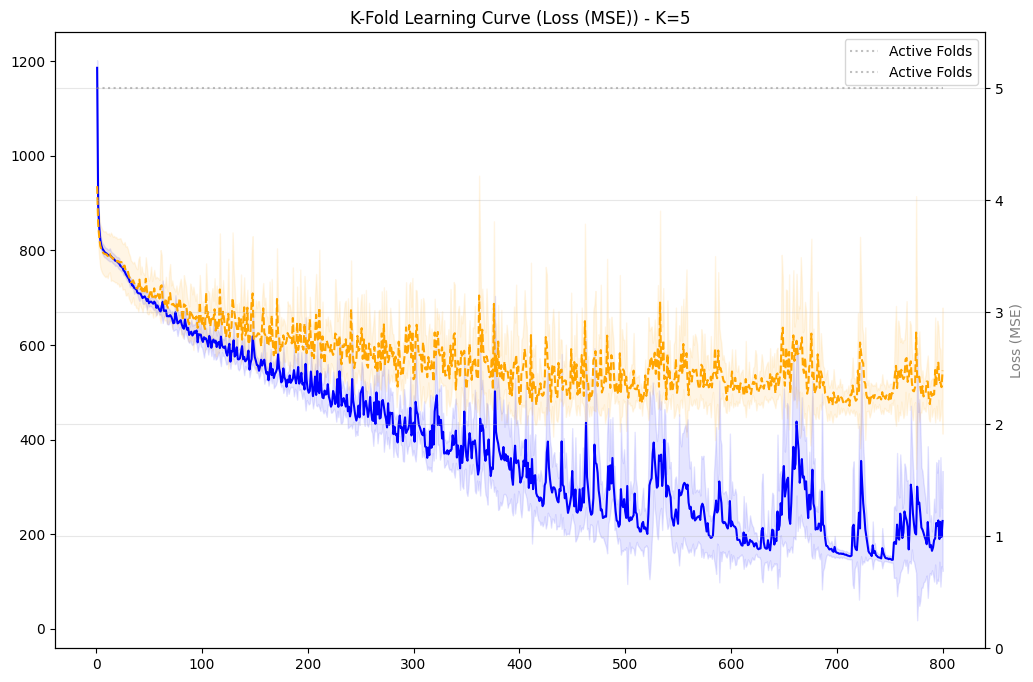

Valore Finale (loss): 545.75629 ± 133.36305


In [19]:
# ==========================================
# 4. LEARNING CURVE CON K-FOLD (METRICA MEE)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import warnings
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer

print("\n=== Generazione K-Fold Learning Curve (MEE) ===")

# 1. Configurazione
run_config = best_config.copy()
# (Opzionale) Aumenta le epoche
# run_config['training']['epochs'] = 1000 

k_folds = 5 

# 2. Dati
X_dev_raw, y_dev = common.load_cup(INT_TRAIN, training=True)
do_normalize = run_config.get('data', {}).get('normalize', False)

# 3. Esecuzione K-Fold
model_dummy = common.build_model(run_config, seed=42)
trainer_dummy = Trainer(model_dummy, verbose=0)

print(f"Esecuzione {k_folds}-Fold CV...")
_, _, histories, _ = kfold_cross_validation(
    X=X_dev_raw,
    y=y_dev,
    model=model_dummy,
    trainer=trainer_dummy,
    k=k_folds,
    epochs=run_config['training']['epochs'],
    batch_size=run_config['training']['batch_size'],
    shuffle=True,
    seed=42,
    verbose=0,
    normalize_data=do_normalize,
    include_reg_in_val=False 
)

# 4. GESTIONE ESTRAMI E SCELTA METRICA
print("Elaborazione dati...")

# Convertiamo tutti gli oggetti history in dizionari
history_dicts = []
for h in histories:
    try:
        history_dicts.append(h.to_dict())
    except AttributeError:
        history_dicts.append(h.history)

# --- LOGICA DI RILEVAMENTO METRICA ---
# Controlliamo le chiavi disponibili nel primo fold
available_keys = history_dicts[0].keys()
print(f"Chiavi disponibili nello storico: {list(available_keys)}")

# Cerchiamo varianti comuni del nome MEE
possible_mee_keys = ['mee', 'MEE', 'mean_euclidean_error']
target_key = None
val_target_key = None

for key in possible_mee_keys:
    if key in available_keys:
        target_key = key
        # Cerchiamo la corrispettiva validazione (es. 'val_mee')
        if f"val_{key}" in available_keys:
            val_target_key = f"val_{key}"
        elif "val_MEE" in available_keys: # Caso specifico se key='MEE'
            val_target_key = "val_MEE"
        break

if target_key:
    print(f"-> Trovata metrica MEE! Plotterò: '{target_key}' e '{val_target_key}'")
    y_label_text = "MEE (Mean Euclidean Error)"
else:
    print("-> ATTENZIONE: Metrica MEE non trovata nello storico. Plotterò la LOSS (MSE).")
    target_key = 'loss'
    val_target_key = 'val_loss' if 'val_loss' in available_keys else None
    y_label_text = "Loss (MSE)"

# 5. ESTRAZIONE E PADDING (NaN)
train_values_list = [h[target_key] for h in history_dicts]
val_values_list = [h[val_target_key] for h in history_dicts] if val_target_key else []

max_len = max(len(h) for h in train_values_list)
train_matrix = np.full((k_folds, max_len), np.nan)
val_matrix = np.full((k_folds, max_len), np.nan)

for i in range(k_folds):
    n = len(train_values_list[i])
    train_matrix[i, :n] = train_values_list[i]
    if val_values_list:
        val_matrix[i, :n] = val_values_list[i]

# 6. CALCOLO STATISTICHE
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    mean_train = np.nanmean(train_matrix, axis=0)
    std_train = np.nanstd(train_matrix, axis=0)
    
    if val_values_list:
        mean_val = np.nanmean(val_matrix, axis=0)
        std_val = np.nanstd(val_matrix, axis=0)
    else:
        mean_val, std_val = None, None

# Pulizia NaN finali
valid_indices = ~np.isnan(mean_train)
mean_train = mean_train[valid_indices]
std_train = std_train[valid_indices]
if mean_val is not None:
    mean_val = mean_val[valid_indices]
    std_val = std_val[valid_indices]

x_axis = range(1, len(mean_train) + 1)

# 7. PLOTTING
plt.figure(figsize=(12, 8))

# Train
plt.plot(x_axis, mean_train, label=f'Train {target_key} (Active Folds)', color='blue')
plt.fill_between(x_axis, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.1)

# Val
if mean_val is not None:
    plt.plot(x_axis, mean_val, label=f'Val {target_key} (Active Folds)', color='orange', linestyle='--')
    plt.fill_between(x_axis, mean_val - std_val, mean_val + std_val, color='orange', alpha=0.1)

# Active Folds (asse destro)
active_folds = np.sum(~np.isnan(train_matrix), axis=0)[:len(mean_train)]
ax2 = plt.gca().twinx()
ax2.plot(x_axis, active_folds, color='gray', linestyle=':', alpha=0.5, label='Active Folds')
ax2.set_ylabel('Active Folds', color='gray')
ax2.set_ylim(0, k_folds + 0.5)

plt.title(f'K-Fold Learning Curve ({y_label_text}) - K={k_folds}')
plt.xlabel('Epochs')
plt.ylabel(y_label_text)

lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper right')

plt.grid(True, alpha=0.3)
plt.show()

if mean_val is not None:
    print(f"Valore Finale ({target_key}): {mean_val[-1]:.5f} ± {std_val[-1]:.5f}")